<a href="https://colab.research.google.com/github/PunPun777/ML-Lab/blob/main/ML_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Program 1:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


In [ ]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df['MedHouseVak'] = housing.target

print("Datset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

Datset shape: (20640, 9)

First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVak  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


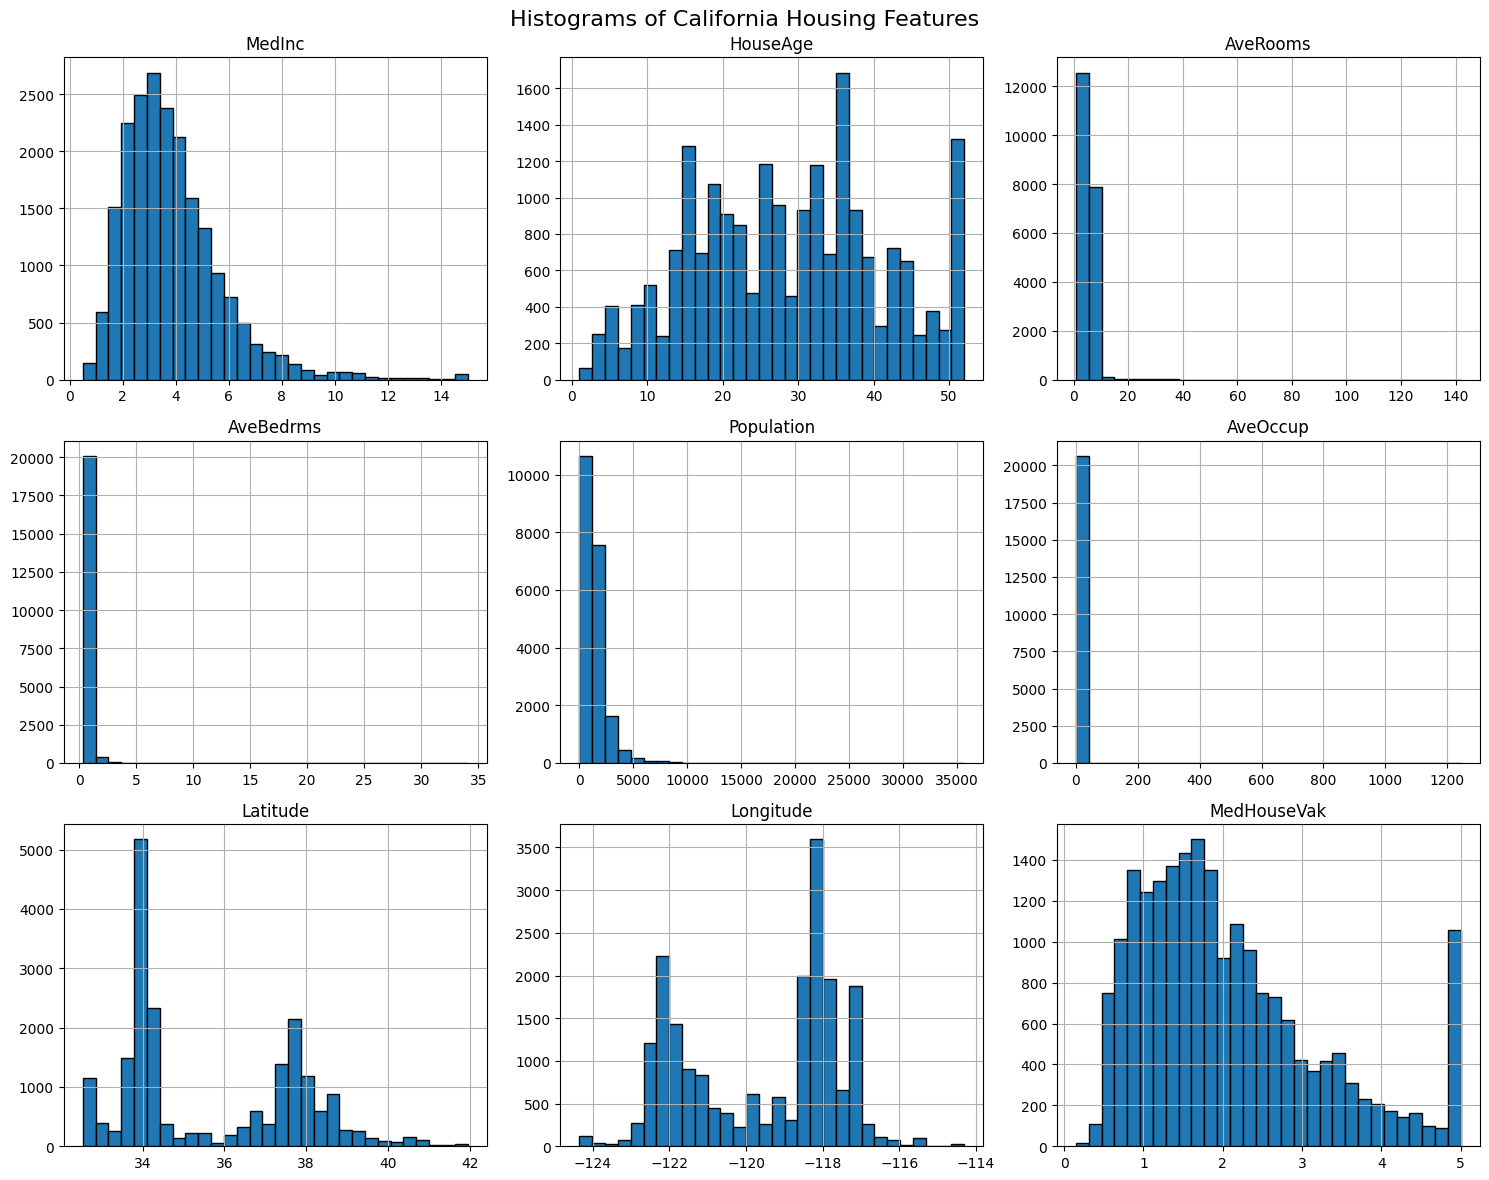

In [ ]:
df.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Histograms of California Housing Features", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

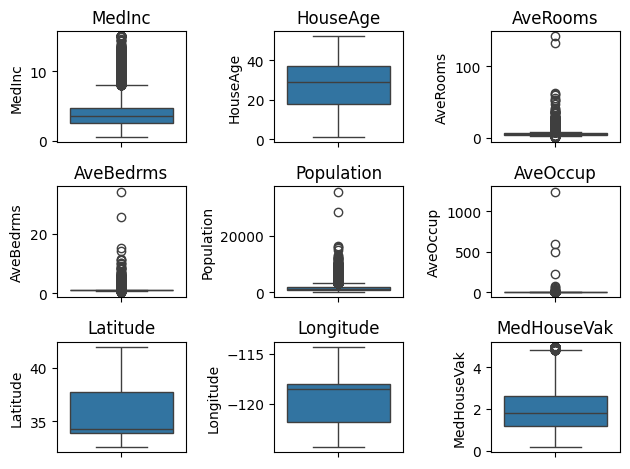

In [ ]:
for i, column in enumerate(df.columns, 1):
  plt.subplot(3, 3, i)
  sns.boxplot(y=df[column])
  plt.title(column)

plt.tight_layout()
plt.show()

In [ ]:
print("Outlier Summary using IQR method:\n")

for column in df.columns:
  q1= df[column].quantile(0.25)
  q3=df[column].quantile(0.75)
  IQR = q3-q1
  lower_bound = q1-1.5*IQR
  upper_bound = q3+1.5*IQR
  outliers = df[(df[column]<lower_bound) | (df[column]>upper_bound)]
  print(f"{column}: {len(outliers)} outliers")

Outlier Summary using IQR method:

MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVak: 1071 outliers


# Program 2:


----Co-relation Matrix---


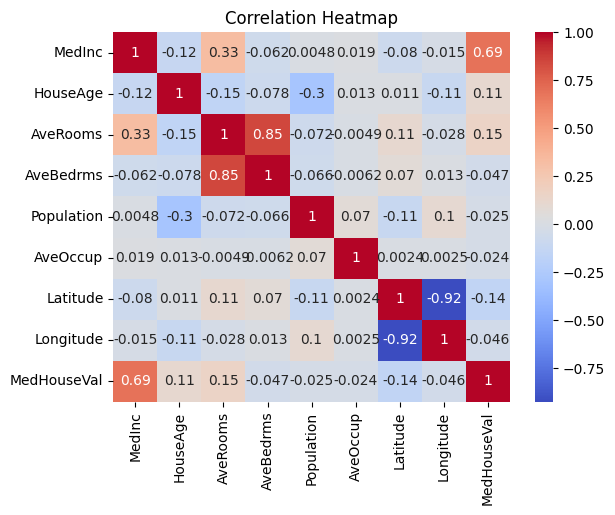

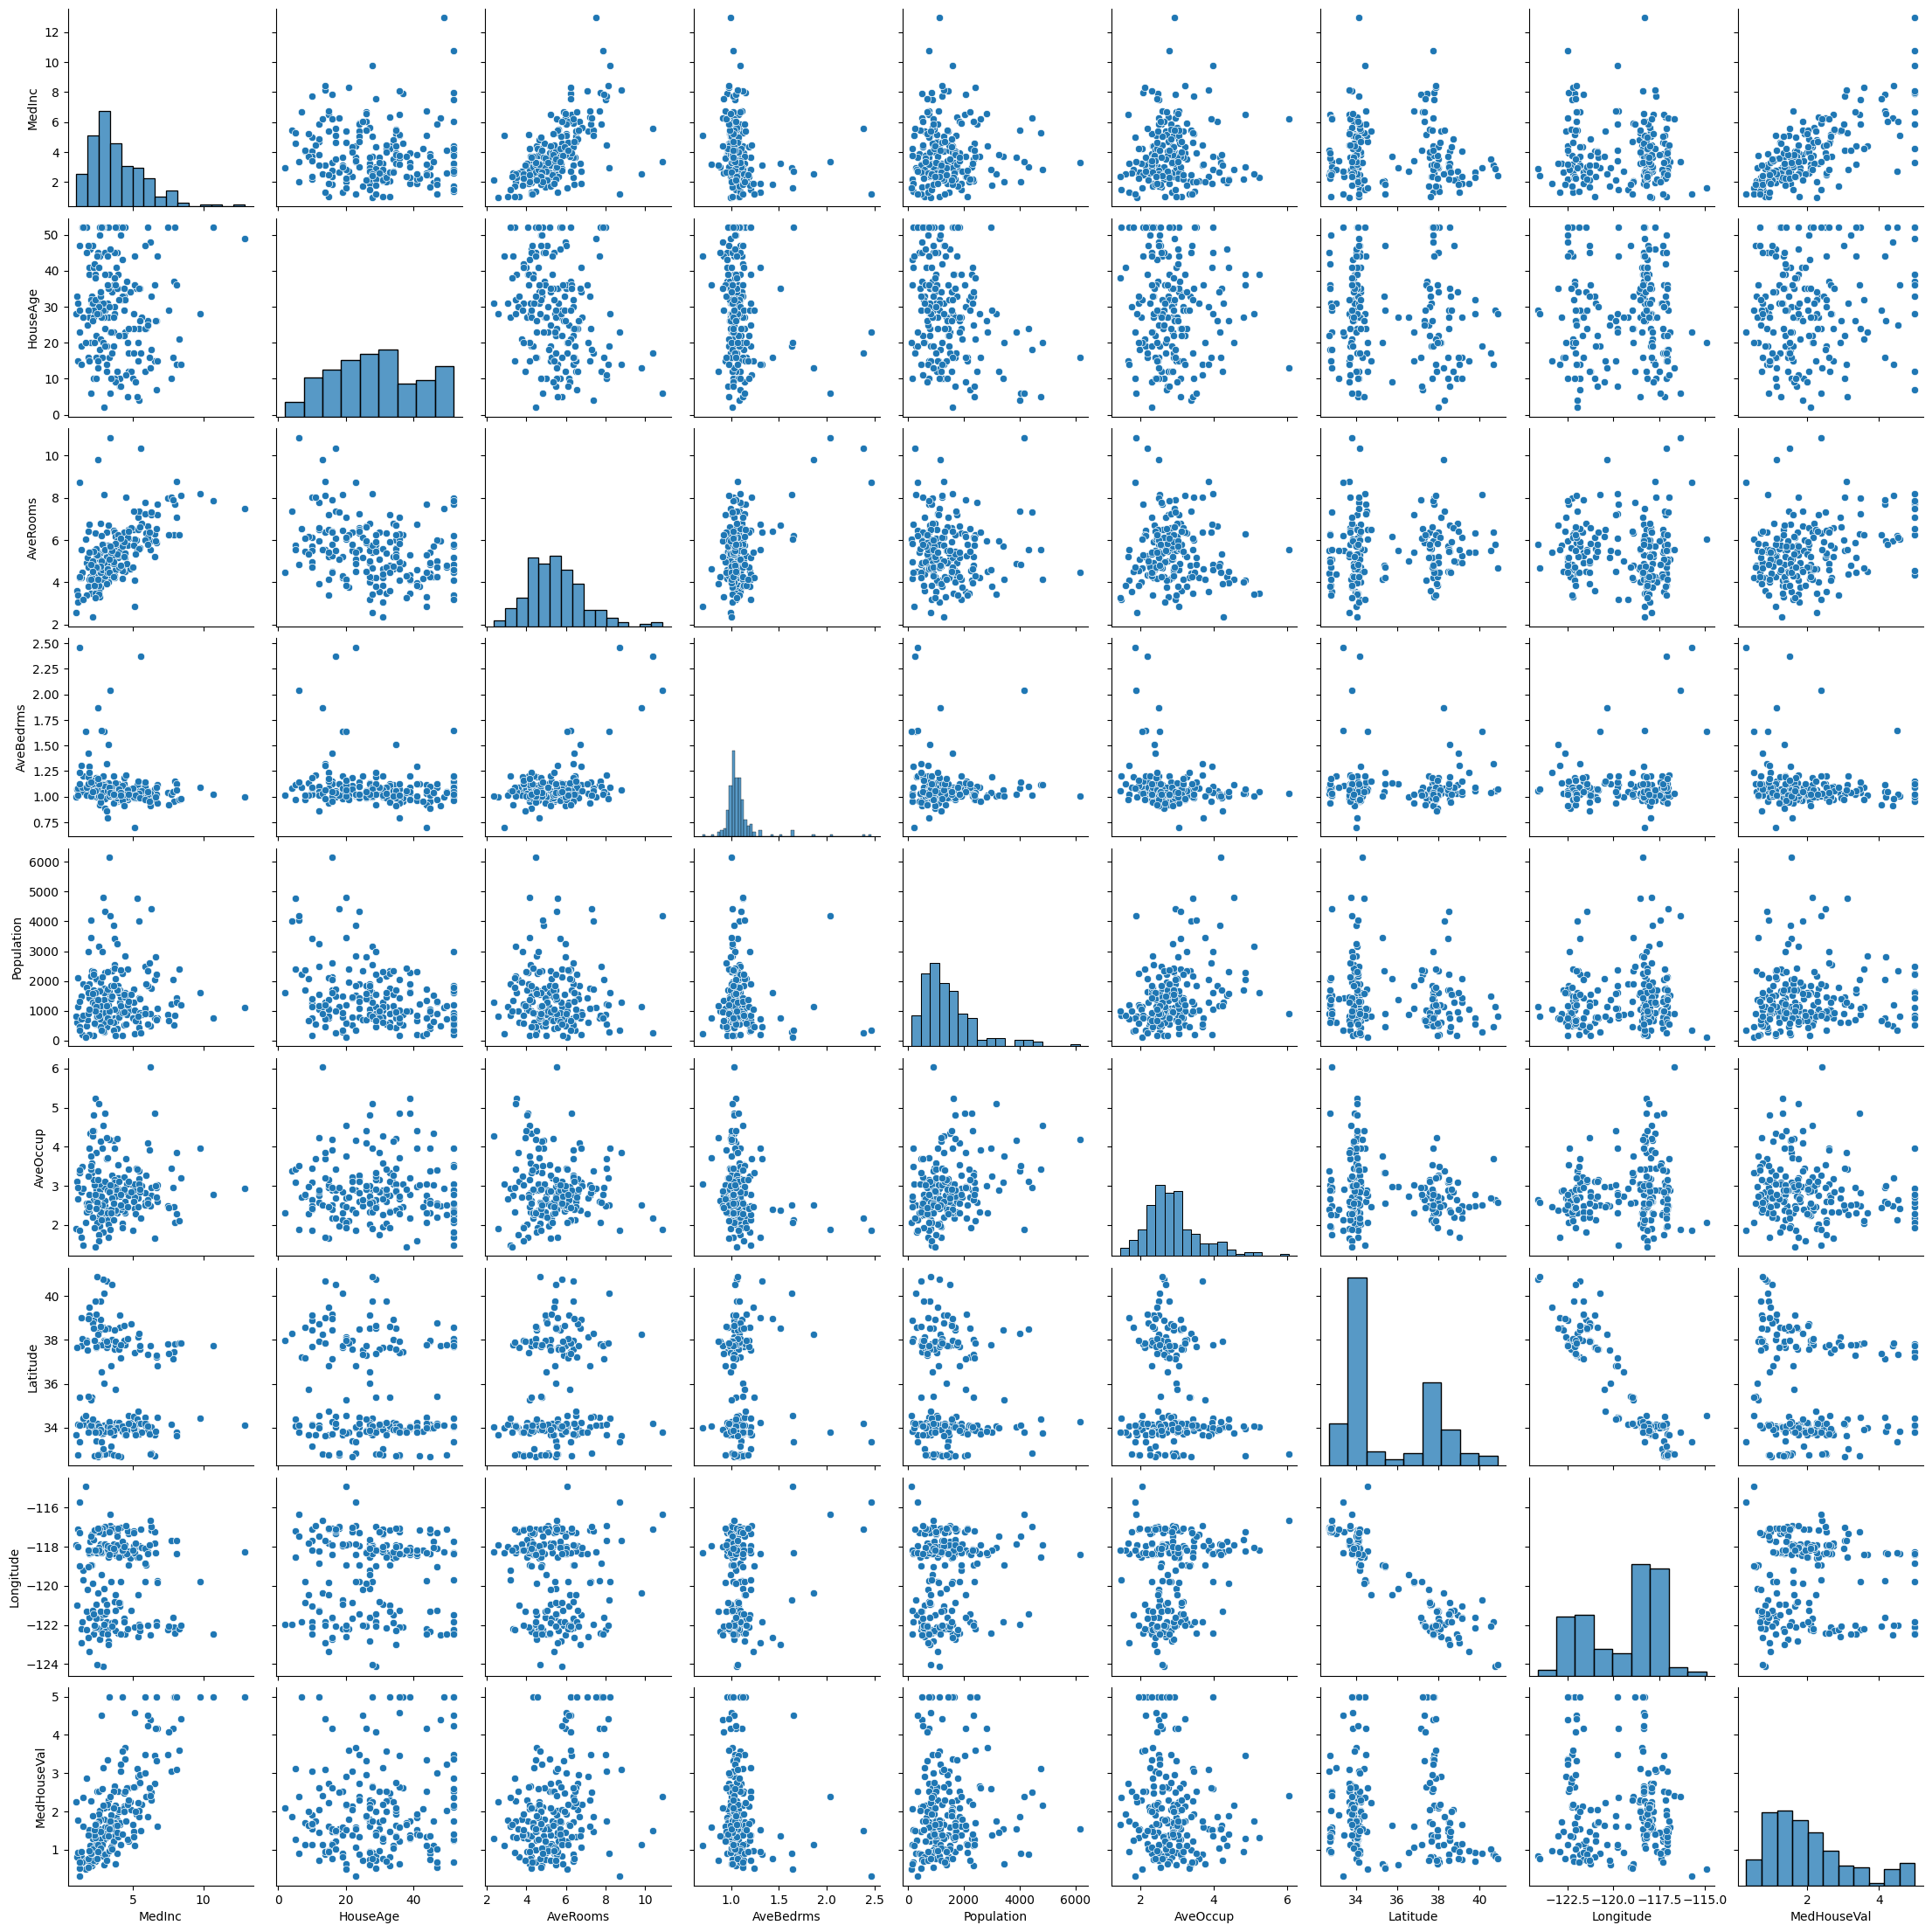

In [ ]:
data = fetch_california_housing(as_frame = True)
df = data.frame
print("\n----Co-relation Matrix---")
cor = df.corr()
sns.heatmap(cor, annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()
sns.pairplot(df.sample(200))
plt.show()

# Program 3:

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

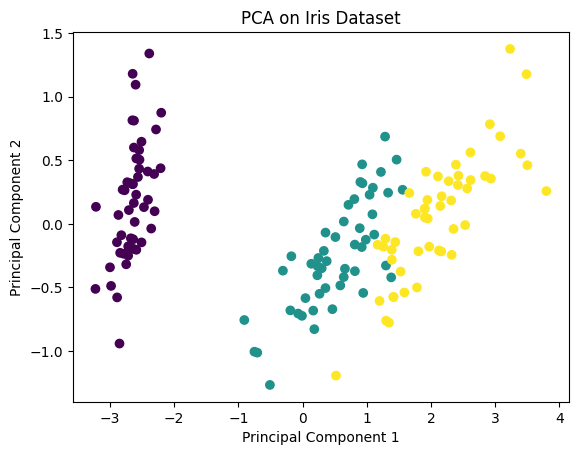

In [ ]:
iris = load_iris()
X = iris.data
Y = iris.target
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y)
plt.title("PCA on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Program 5

k=1 	 accuracy=0.48
k=2 	 accuracy=0.48
k=3 	 accuracy=0.5
k=4 	 accuracy=0.5
k=5 	 accuracy=0.5
k=20 	 accuracy=0.5
k=30 	 accuracy=0.5


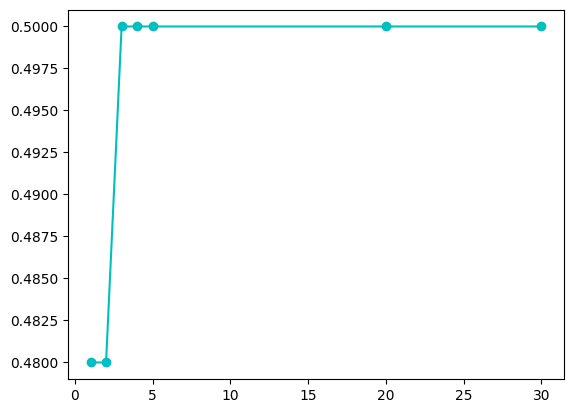

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X=np.random.rand(100, 1)
Y = np.array([1 if x<=0.5 else 2 for x in X[:50]])

X_train, Y_train = X[:50], Y
X_test = X[50:]
Y_test = np.array([1 if x<=0.5 else 2 for x in X_train])

kv = [1, 2, 3, 4, 5, 20, 30]
acc = []

for k in kv:
  model = KNeighborsClassifier(n_neighbors = k)
  model.fit(X_train, Y_train)
  Y_pred = model.predict(X_test)
  accuracy = accuracy_score(Y_test, Y_pred)
  acc.append(accuracy)
  print(f"k={k} \t accuracy={accuracy}")
plt.plot(kv, acc, marker='o', linestyle='-', color='c')

# Program 4

In [ ]:
import csv

with open("training_data.csv") as f:
    data = list(csv.reader(f))

attributes = data[0][:-1]
examples = data[1:]

hypothesis = ['0'] * len(attributes)

for row in examples:
    if row[-1].lower() == "yes":
        for i in range(len(attributes)):
            if hypothesis[i] == '0':
                hypothesis[i] = row[i]
            elif hypothesis[i] != row[i]:
                hypothesis[i] = '?'

print("Final Hypothesis:", hypothesis)

FileNotFoundError: [Errno 2] No such file or directory: 'training_data.csv'

# Program 6

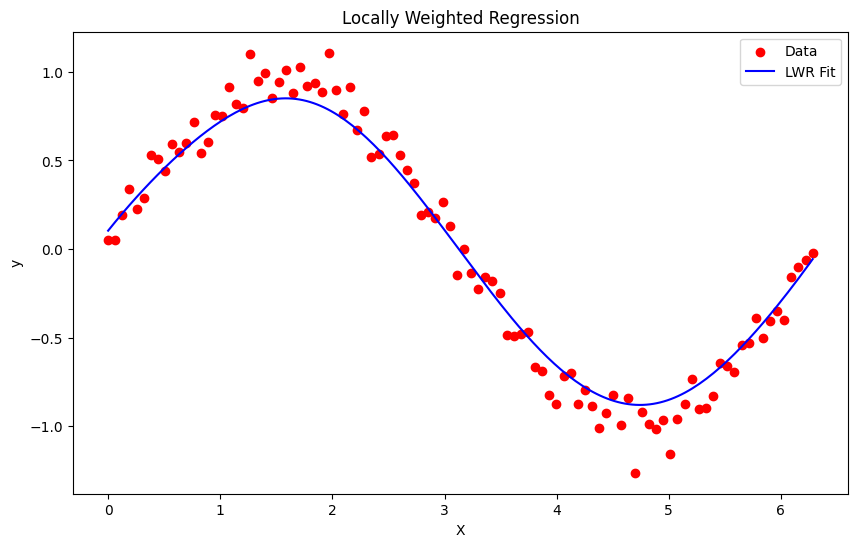

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))

def lwr(x, X, y, tau):
    W = np.diag([kernel(x, xi, tau) for xi in X])
    theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)
    return x @ theta

np.random.seed(42)

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1*np.random.randn(100)

X_b = np.c_[np.ones(X.shape), X]

x_test = np.linspace(0, 2*np.pi, 200)
x_test_b = np.c_[np.ones(x_test.shape), x_test]

tau = 0.5

y_pred = np.array([lwr(xi, X_b, y, tau) for xi in x_test_b])

plt.figure(figsize=(10,6))
plt.scatter(X, y, color='red', label='Data')
plt.plot(x_test, y_pred, color='blue', label='LWR Fit')
plt.legend()
plt.title('Locally Weighted Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Program 7

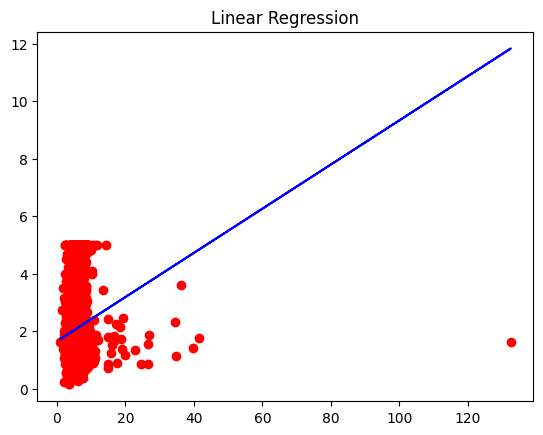

Linear R2: 0.013795337532284901


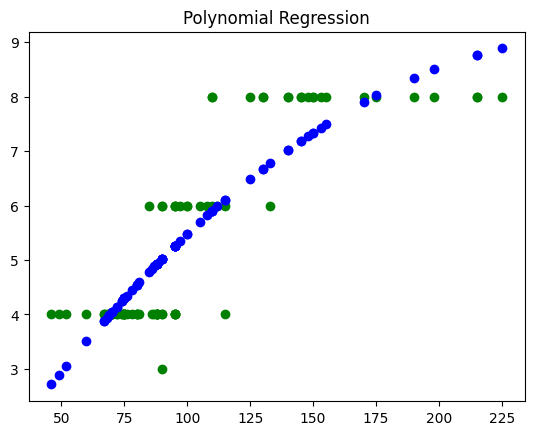

Polynomial R2: 0.7505650609469621


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data[:, 2].reshape(-1,1)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_pred, color='blue')
plt.title("Linear Regression")
plt.show()

print("Linear R2:", r2_score(y_test, y_pred))


# Polynomial Regression (Auto MPG)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
cols = ["mpg","cyl","disp","hp","wt","acc","year","org"]
data = pd.read_csv(url, sep=r'\s+', names=cols, na_values="?").dropna()

X = data["disp"].values.reshape(-1,1)
y = data["mpg"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(2)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_p, y_train)
y_pred = model.predict(X_test_p)

plt.scatter(X_test, y_test, color='green')
plt.scatter(X_test, y_pred, color='blue')
plt.title("Polynomial Regression")
plt.show()

print("Polynomial R2:", r2_score(y_test, y_pred))

# alternative 7th program

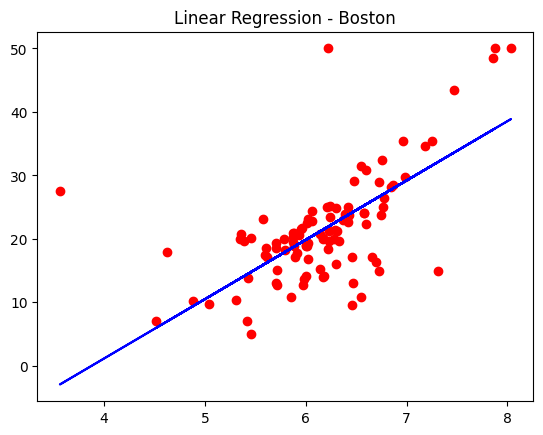

Linear R2: 0.3707569232254778


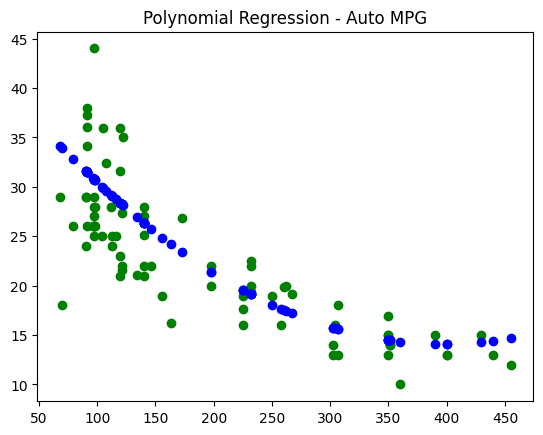

Polynomial R2: 0.5954385038809804


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Linear Regression (Boston Dataset)
boston = pd.read_csv("Boston.csv")

X = boston[['rm']].values
y = boston['medv'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_pred, color='blue')
plt.title("Linear Regression - Boston")
plt.show()

print("Linear R2:", r2_score(y_test, y_pred))


# Polynomial Regression (Auto MPG Dataset)
mpg = pd.read_csv("auto-mpg.csv")

mpg = mpg.replace('?', np.nan).dropna()

X = mpg[['displacement']].values
y = mpg['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(2)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_p, y_train)
y_pred = model.predict(X_test_p)

plt.scatter(X_test, y_test, color='green')
plt.scatter(X_test, y_pred, color='blue')
plt.title("Polynomial Regression - Auto MPG")
plt.show()

print("Polynomial R2:", r2_score(y_test, y_pred))

# Program 8

Accuracy: 94.74%
Prediction: Benign


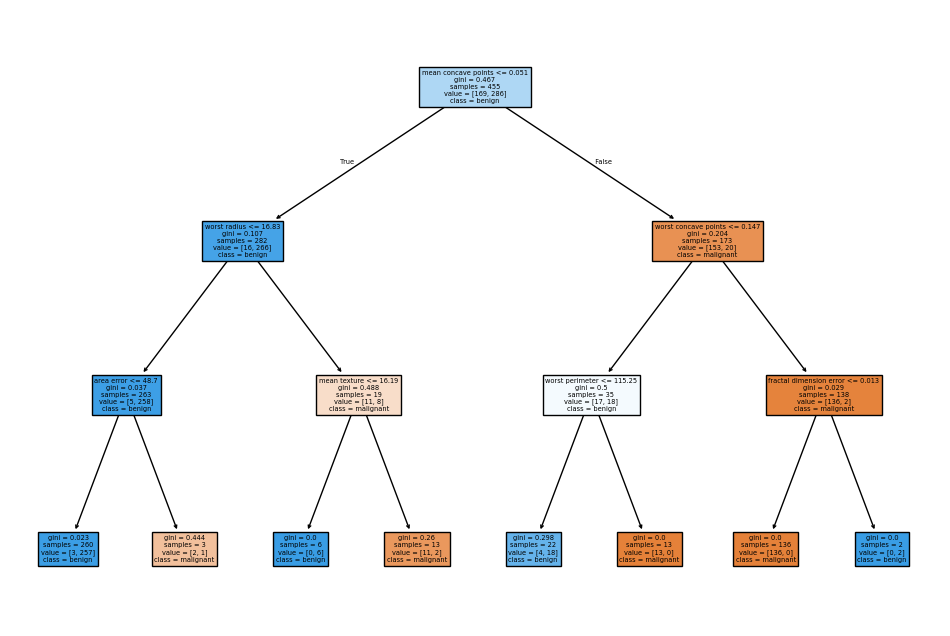

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

sample = X_test[0].reshape(1, -1)
pred = clf.predict(sample)[0]
print("Prediction:", "Benign" if pred == 1 else "Malignant")

plt.figure(figsize=(12,8))
tree.plot_tree(clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()

# Program 9

Accuracy: 77.50%


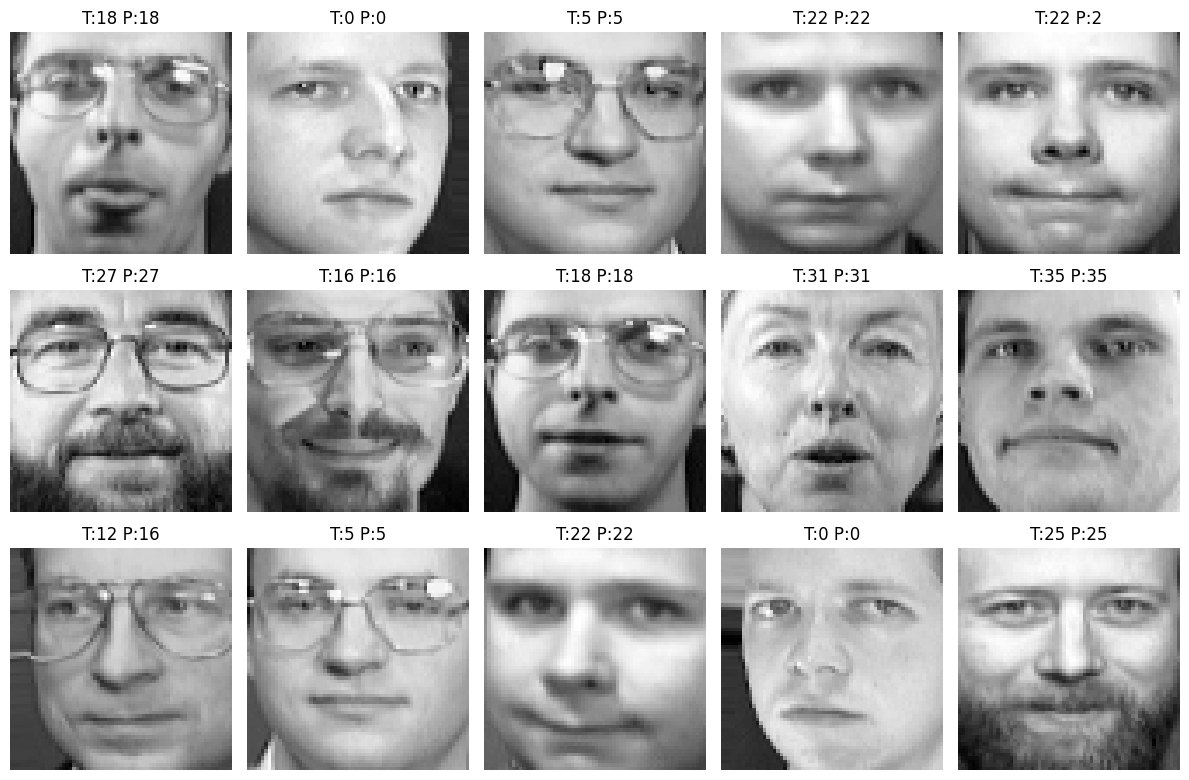

In [ ]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"T:{y_test[i]} P:{y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Program 10

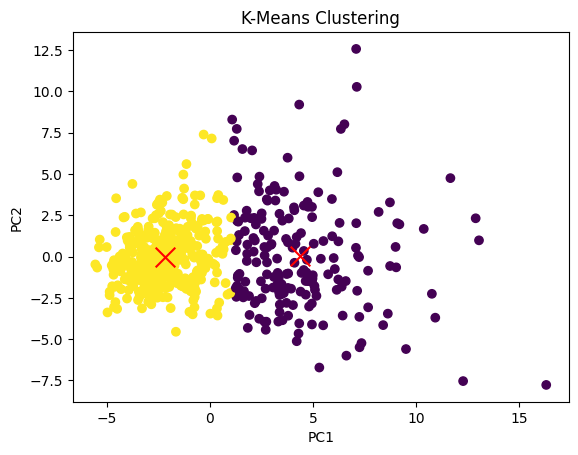

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
X = data.data

X = StandardScaler().fit_transform(X)

X_pca = PCA(n_components=2).fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='x', s=200)

plt.title("K-Means Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()